In [4]:
import requests
from supabase import create_client
from dotenv import load_dotenv
import os
import time

load_dotenv()
supabase = create_client(os.getenv("SUPABASE_URL"), os.getenv("SUPABASE_KEY"))

# Small-analysis scope: one full calendar year (captures both monsoon cycles),
# 5 locations covering every mode combination — not all 15, not the full 2024-2026 range.
START, END = "2025-01-01", "2025-12-31"

TOURISM_ONLY = {"Mirissa", "Hikkaduwa", "Unawatuna", "Bentota", "Arugam Bay"}

ANALYSIS_LOCATIONS = [
    {"name": "Mirissa",  "lat": 5.948, "lon": 80.455},   # Tourism only
    {"name": "Galle",    "lat": 6.030, "lon": 80.217},   # all three modes
    {"name": "Chilaw",   "lat": 7.576, "lon": 79.796},   # Fisherman + Emergency
    {"name": "Tangalle", "lat": 6.025, "lon": 80.793},   # Fisherman only
    {"name": "Matara",   "lat": 5.948, "lon": 80.535},   # Emergency only
]

def already_in_silver(name):
    result = supabase.table("silver_hourly") \
        .select("timestamp", count="exact") \
        .eq("location_name", name) \
        .execute()
    return result.count is not None and result.count > 0

def fetch(url, hourly_vars, lat, lon, retries=4, timeout=90):
    for attempt in range(retries):
        try:
            r = requests.get(url, params={
                "latitude": lat, "longitude": lon,
                "hourly": hourly_vars,
                "start_date": START, "end_date": END,
                "timezone": "Asia/Colombo"
            }, timeout=timeout)
            data = r.json()
            if "hourly" not in data:
                print(f"    API error: {data}")
                return None
            return data
        except Exception as e:
            print(f"    Attempt {attempt+1} failed: {e}")
            time.sleep(4)
    return None

def validate(name, m1, m2, m3, w, aq, is_tourism_only):
    """Return (is_suitable, reason). Strict on core variables, tolerant on
    sea_surface_temperature only, given a confirmed 13-day nationwide gap
    (2025-01-29 to 2025-02-11) in Open-Meteo's marine SST source."""
    endpoints = {"marine_waves": m1, "marine_swell": m2, "weather": w, "air_quality": aq}
    if not is_tourism_only:
        endpoints["marine_ocean"] = m3

    for label, d in endpoints.items():
        if d is None:
            return False, f"{label} fetch failed"

    time_arrays = [d["hourly"]["time"] for d in endpoints.values()]
    if not all(t == time_arrays[0] for t in time_arrays):
        return False, "timestamp arrays not aligned across endpoints"

    # Variables with zero null tolerance
    strict_keys = {
        "marine_waves": ["wave_height", "wave_period", "wave_direction"],
        "marine_swell": ["swell_wave_height", "swell_wave_period", "wind_wave_height"],
        "weather": ["wind_speed_10m", "precipitation", "surface_pressure"],
        "air_quality": ["uv_index", "pm2_5"],
    }
    for label, keys in strict_keys.items():
        d = endpoints[label]
        for k in keys:
            vals = d["hourly"].get(k, [])
            null_count = sum(1 for v in vals if v is None)
            if null_count:
                return False, f"{label}.{k} has {null_count} null values (zero tolerance)"

    # Tolerant check: sea_surface_temperature and ocean_current fields only,
    # given the confirmed shared data-source gap
    if not is_tourism_only and m3 is not None:
        for k in ["sea_surface_temperature", "ocean_current_velocity", "ocean_current_direction"]:
            vals = m3["hourly"].get(k, [])
            null_count = sum(1 for v in vals if v is None)
            tolerance = 0.05  # 5%
            if null_count / len(vals) > tolerance:
                return False, f"marine_ocean.{k} has {null_count} nulls ({null_count/len(vals):.1%}) — exceeds tolerance"
            elif null_count:
                print(f"    NOTE: marine_ocean.{k} has {null_count} nulls ({null_count/len(vals):.1%}) — within tolerance, proceeding")

    # Sanity checks
    if any(v is not None and v < 0 for v in m1["hourly"]["wave_height"]):
        return False, "negative wave_height values found"
    if any(v is not None and v < 0 for v in w["hourly"]["wind_speed_10m"]):
        return False, "negative wind_speed values found"

    return True, "OK"

for loc in ANALYSIS_LOCATIONS:
    name, lat, lon = loc["name"], loc["lat"], loc["lon"]
    print(f"\n=== {name} ===")

    if already_in_silver(name):
        print(f"  Skipping — Silver data already exists for {name}.")
        continue

    m1 = fetch("https://marine-api.open-meteo.com/v1/marine",
               "wave_height,wave_period,wave_direction", lat, lon)

    m2 = fetch("https://marine-api.open-meteo.com/v1/marine",
               "swell_wave_height,swell_wave_direction,swell_wave_period,wind_wave_height", lat, lon)

    is_tourism_only = name in TOURISM_ONLY
    if is_tourism_only:
        m3 = None
        print("  marine_ocean skipped — tourism-only location")
    else:
        m3 = fetch("https://marine-api.open-meteo.com/v1/marine",
                   "sea_surface_temperature,ocean_current_velocity,ocean_current_direction", lat, lon)

    w = fetch("https://archive-api.open-meteo.com/v1/archive",
              "wind_speed_10m,wind_gusts_10m,precipitation,surface_pressure", lat, lon)

    aq = fetch("https://air-quality-api.open-meteo.com/v1/air-quality",
               "uv_index,pm2_5", lat, lon)

    suitable, reason = validate(name, m1, m2, m3, w, aq, is_tourism_only)
    if not suitable:
        print(f"  NOT SUITABLE — {reason}. Skipping Silver write for {name}.")
        continue

    print(f"  Validation passed ({reason}). Writing Bronze + Silver...")

    supabase.table("bronze_raw").insert({
        "location_name": name,
        "api_source": "small_analysis_fetch",
        "raw_json": {
            "marine_waves": m1, "marine_swell": m2, "marine_ocean": m3,
            "weather": w, "air_quality": aq
        }
    }).execute()

    times = m1["hourly"]["time"]
    rows = []
    for i in range(len(times)):
        rows.append({
            "location_name":           name,
            "timestamp":               times[i],
            "wave_height":             m1["hourly"]["wave_height"][i],
            "wave_period":             m1["hourly"]["wave_period"][i],
            "wave_direction":          m1["hourly"]["wave_direction"][i],
            "swell_height":            m2["hourly"]["swell_wave_height"][i],
            "swell_period":            m2["hourly"]["swell_wave_period"][i],
            "swell_direction":         m2["hourly"]["swell_wave_direction"][i],
            "wind_wave_height":        m2["hourly"]["wind_wave_height"][i],
            "sea_surface_temp":        m3["hourly"]["sea_surface_temperature"][i] if m3 else None,
            "ocean_current_velocity":  m3["hourly"]["ocean_current_velocity"][i] if m3 else None,
            "ocean_current_direction": m3["hourly"]["ocean_current_direction"][i] if m3 else None,
            "sea_level_height":        None,
            "wind_speed":              w["hourly"]["wind_speed_10m"][i],
            "wind_gust":               w["hourly"]["wind_gusts_10m"][i],
            "precipitation":           w["hourly"]["precipitation"][i],
            "atmospheric_pressure":    w["hourly"]["surface_pressure"][i],
            "uv_index":                aq["hourly"]["uv_index"][i],
            "pm25":                    aq["hourly"]["pm2_5"][i],
        })

    supabase.table("silver_hourly").upsert(rows, on_conflict="location_name,timestamp").execute()
    print(f"  Inserted {len(rows)} Silver rows for {name}.")

    time.sleep(2)

print("\nSmall-analysis fetch complete.")


=== Mirissa ===
  Skipping — Silver data already exists for Mirissa.

=== Galle ===
    NOTE: marine_ocean.sea_surface_temperature has 312 nulls (3.6%) — within tolerance, proceeding
  Validation passed (OK). Writing Bronze + Silver...
  Inserted 8760 Silver rows for Galle.

=== Chilaw ===
    NOTE: marine_ocean.sea_surface_temperature has 312 nulls (3.6%) — within tolerance, proceeding
  Validation passed (OK). Writing Bronze + Silver...
  Inserted 8760 Silver rows for Chilaw.

=== Tangalle ===
    NOTE: marine_ocean.sea_surface_temperature has 312 nulls (3.6%) — within tolerance, proceeding
  Validation passed (OK). Writing Bronze + Silver...
  Inserted 8760 Silver rows for Tangalle.

=== Matara ===
    NOTE: marine_ocean.sea_surface_temperature has 312 nulls (3.6%) — within tolerance, proceeding
  Validation passed (OK). Writing Bronze + Silver...
  Inserted 8760 Silver rows for Matara.

Small-analysis fetch complete.


In [3]:
import requests

def check_null_pattern(lat, lon, name):
    r = requests.get("https://marine-api.open-meteo.com/v1/marine", params={
        "latitude": lat, "longitude": lon,
        "hourly": "sea_surface_temperature",
        "start_date": "2025-01-01", "end_date": "2025-12-31",
        "timezone": "Asia/Colombo"
    }, timeout=60)
    data = r.json()
    times = data["hourly"]["time"]
    vals = data["hourly"]["sea_surface_temperature"]
    null_times = [t for t, v in zip(times, vals) if v is None]
    print(f"{name}: {len(null_times)} nulls | first: {null_times[0] if null_times else None} | last: {null_times[-1] if null_times else None}")
    return set(null_times)

sets = {}
for loc in [("Galle", 6.030, 80.217), ("Chilaw", 7.576, 79.796),
            ("Tangalle", 6.025, 80.793), ("Matara", 5.948, 80.535)]:
    name, lat, lon = loc
    sets[name] = check_null_pattern(lat, lon, name)

# Check if it's the exact same timestamps everywhere
common = set.intersection(*sets.values())
print(f"\nNull timestamps common to all 4 locations: {len(common)} out of {len(sets['Galle'])}")

Galle: 312 nulls | first: 2025-01-29T11:00 | last: 2025-02-11T10:00
Chilaw: 312 nulls | first: 2025-01-29T11:00 | last: 2025-02-11T10:00
Tangalle: 312 nulls | first: 2025-01-29T11:00 | last: 2025-02-11T10:00
Matara: 312 nulls | first: 2025-01-29T11:00 | last: 2025-02-11T10:00

Null timestamps common to all 4 locations: 312 out of 312


ADF test on wave_height (Galle): statistic=-1.984, p-value=0.2936
  -> non-stationary (differencing needed — supports SARIMA's 'I' term)


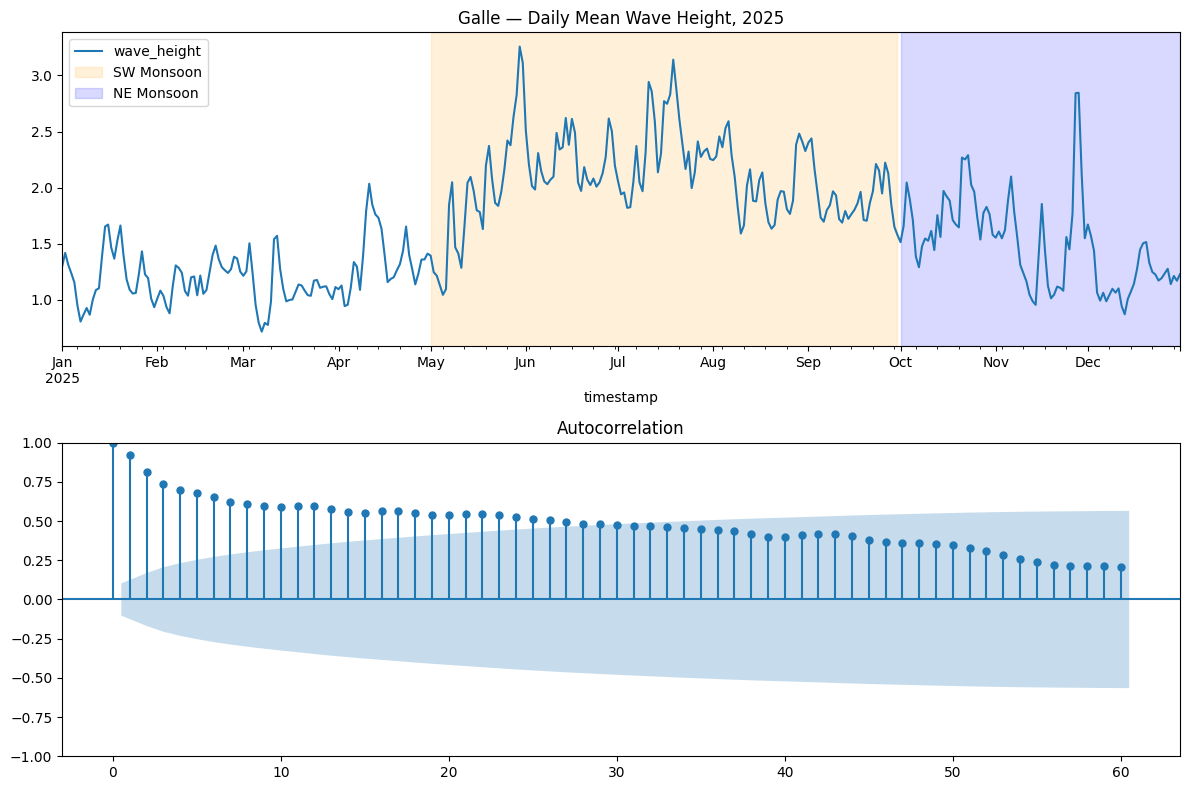

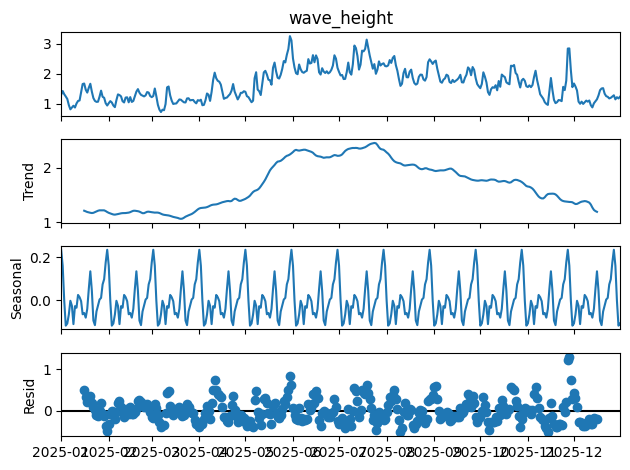

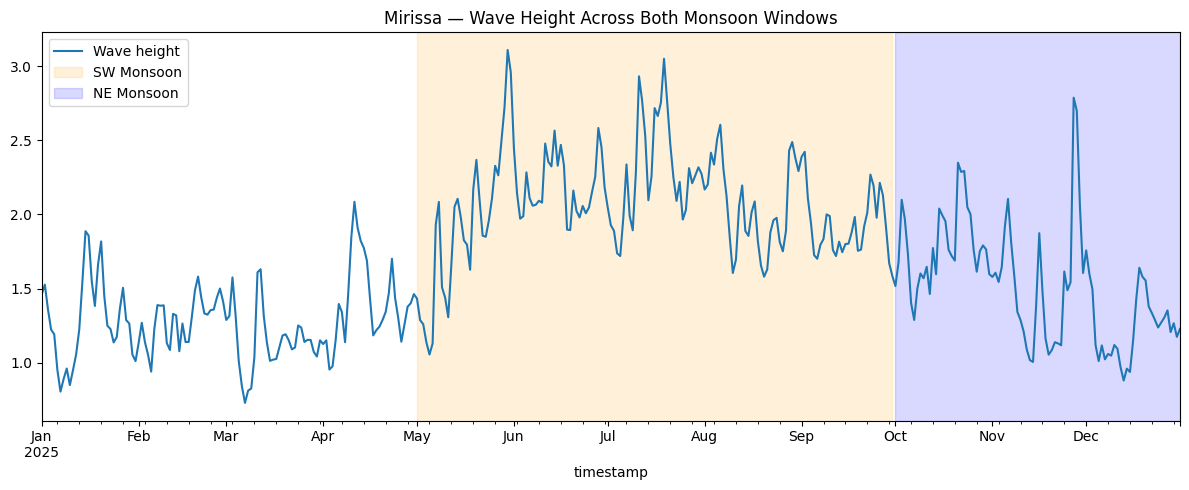


Mirissa mean wave_height — SW monsoon: 2.07, NE monsoon: 1.52, inter-monsoon: 1.28
Two distinct elevated periods vs. the calmer inter-monsoon window would support dual-seasonality modelling.

Matara — threshold-based danger proxy distribution (feasibility check only):
  Safe      :  6382 hours (72.85%)
  Caution   :  2328 hours (26.58%)
  Dangerous :    50 hours ( 0.57%)

If 'Dangerous' is a small minority of hours, this supports the class-imbalance
justification for a tree-based ensemble stated in the proposal.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from supabase import create_client
from dotenv import load_dotenv
import os
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

load_dotenv()
supabase = create_client(os.getenv("SUPABASE_URL"), os.getenv("SUPABASE_KEY"))

def load_location(name):
    all_rows = []
    page_size = 1000
    offset = 0
    while True:
        result = supabase.table("silver_hourly") \
            .select("*") \
            .eq("location_name", name) \
            .order("timestamp") \
            .range(offset, offset + page_size - 1) \
            .execute()
        if not result.data:
            break
        all_rows.extend(result.data)
        offset += page_size
    df = pd.DataFrame(all_rows)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.set_index("timestamp").sort_index()
    return df

# ---------- 1. Fisherman mode: wave_height seasonality + autocorrelation (Galle) ----------
galle = load_location("Galle")
daily_wave = galle["wave_height"].resample("D").mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
daily_wave.plot(ax=axes[0], title="Galle — Daily Mean Wave Height, 2025")
axes[0].axvspan("2025-05-01", "2025-09-30", alpha=0.15, color="orange", label="SW Monsoon")
axes[0].axvspan("2025-10-01", "2025-12-31", alpha=0.15, color="blue", label="NE Monsoon")
axes[0].legend()

adf_result = adfuller(daily_wave.dropna())
print(f"ADF test on wave_height (Galle): statistic={adf_result[0]:.3f}, p-value={adf_result[1]:.4f}")
print("  -> stationary" if adf_result[1] < 0.05 else "  -> non-stationary (differencing needed — supports SARIMA's 'I' term)")

plot_acf(daily_wave.dropna(), lags=60, ax=axes[1])
plt.tight_layout()
plt.savefig("galle_wave_seasonality.png", dpi=150)
plt.show()

seasonal_period = 365 if len(daily_wave.dropna()) > 730 else 30
try:
    decomp = seasonal_decompose(daily_wave.dropna(), period=30, model="additive")
    decomp.plot()
    plt.savefig("galle_wave_decomposition.png", dpi=150)
    plt.show()
except Exception as e:
    print(f"Decomposition needs a longer series for a clean annual period: {e}")


# ---------- 2. Tourism mode: dual-seasonality check (Mirissa) ----------
mirissa = load_location("Mirissa")
daily_tourism = mirissa[["wave_height", "wind_speed", "uv_index", "precipitation"]].resample("D").mean()

fig, ax = plt.subplots(figsize=(12, 5))
daily_tourism["wave_height"].plot(ax=ax, label="Wave height")
ax.axvspan("2025-05-01", "2025-09-30", alpha=0.15, color="orange", label="SW Monsoon")
ax.axvspan("2025-10-01", "2025-12-31", alpha=0.15, color="blue", label="NE Monsoon")
ax.set_title("Mirissa — Wave Height Across Both Monsoon Windows")
ax.legend()
plt.tight_layout()
plt.savefig("mirissa_dual_seasonality.png", dpi=150)
plt.show()

sw_mean = daily_tourism.loc["2025-05-01":"2025-09-30", "wave_height"].mean()
ne_mean = daily_tourism.loc["2025-10-01":"2025-12-31", "wave_height"].mean()
off_mean = daily_tourism.loc["2025-02-01":"2025-04-30", "wave_height"].mean()
print(f"\nMirissa mean wave_height — SW monsoon: {sw_mean:.2f}, NE monsoon: {ne_mean:.2f}, inter-monsoon: {off_mean:.2f}")
print("Two distinct elevated periods vs. the calmer inter-monsoon window would support dual-seasonality modelling.")


# ---------- 3. Emergency mode: class imbalance check (Matara) ----------
matara = load_location("Matara")

# Simple threshold-based danger proxy — NOT the final model, just a feasibility check
# on whether "dangerous" conditions are actually rare in this data.
def danger_level(row):
    if row["wave_height"] > 3.0 or row["wind_speed"] > 40:
        return "Dangerous"
    elif row["wave_height"] > 2.0 or row["wind_speed"] > 25:
        return "Caution"
    return "Safe"

matara["danger_proxy"] = matara.apply(danger_level, axis=1)
class_counts = matara["danger_proxy"].value_counts()
class_pct = matara["danger_proxy"].value_counts(normalize=True) * 100

print("\nMatara — threshold-based danger proxy distribution (feasibility check only):")
for level in ["Safe", "Caution", "Dangerous"]:
    count = class_counts.get(level, 0)
    pct = class_pct.get(level, 0)
    print(f"  {level:10s}: {count:5d} hours ({pct:5.2f}%)")

print("\nIf 'Dangerous' is a small minority of hours, this supports the class-imbalance")
print("justification for a tree-based ensemble stated in the proposal.")

In [6]:
import requests
from supabase import create_client
from dotenv import load_dotenv
import os
import time

load_dotenv()
supabase = create_client(os.getenv("SUPABASE_URL"), os.getenv("SUPABASE_KEY"))

# Extending the same 5 locations back to 2024 for multi-year seasonal analysis
START, END = "2024-01-01", "2024-12-31"

TOURISM_ONLY = {"Mirissa", "Hikkaduwa", "Unawatuna", "Bentota", "Arugam Bay"}

ANALYSIS_LOCATIONS = [
    {"name": "Mirissa",  "lat": 5.948, "lon": 80.455},
    {"name": "Galle",    "lat": 6.030, "lon": 80.217},
    {"name": "Chilaw",   "lat": 7.576, "lon": 79.796},
    {"name": "Tangalle", "lat": 6.025, "lon": 80.793},
    {"name": "Matara",   "lat": 5.948, "lon": 80.535},
]

def already_have_range(name, start, end):
    """Range-aware check — does Silver already contain rows for THIS location
    AND this specific date range, not just any data for the location."""
    result = supabase.table("silver_hourly") \
        .select("timestamp", count="exact") \
        .eq("location_name", name) \
        .gte("timestamp", f"{start}T00:00:00") \
        .lte("timestamp", f"{end}T23:59:59") \
        .execute()
    return result.count is not None and result.count > 0

def fetch(url, hourly_vars, lat, lon, retries=4, timeout=90):
    for attempt in range(retries):
        try:
            r = requests.get(url, params={
                "latitude": lat, "longitude": lon,
                "hourly": hourly_vars,
                "start_date": START, "end_date": END,
                "timezone": "Asia/Colombo"
            }, timeout=timeout)
            data = r.json()
            if "hourly" not in data:
                print(f"    API error: {data}")
                return None
            return data
        except Exception as e:
            print(f"    Attempt {attempt+1} failed: {e}")
            time.sleep(4)
    return None

def validate(name, m1, m2, m3, w, aq, is_tourism_only):
    """Same structure as the 2025 validation — does NOT assume the same
    SST gap dates as 2025; detects whatever gap exists in this year's data."""
    endpoints = {"marine_waves": m1, "marine_swell": m2, "weather": w, "air_quality": aq}
    if not is_tourism_only:
        endpoints["marine_ocean"] = m3

    for label, d in endpoints.items():
        if d is None:
            return False, f"{label} fetch failed"

    time_arrays = [d["hourly"]["time"] for d in endpoints.values()]
    if not all(t == time_arrays[0] for t in time_arrays):
        return False, "timestamp arrays not aligned across endpoints"

    strict_keys = {
        "marine_waves": ["wave_height", "wave_period", "wave_direction"],
        "marine_swell": ["swell_wave_height", "swell_wave_period", "wind_wave_height"],
        "weather": ["wind_speed_10m", "precipitation", "surface_pressure"],
        "air_quality": ["uv_index", "pm2_5"],
    }
    for label, keys in strict_keys.items():
        d = endpoints[label]
        for k in keys:
            vals = d["hourly"].get(k, [])
            null_count = sum(1 for v in vals if v is None)
            if null_count:
                return False, f"{label}.{k} has {null_count} null values (zero tolerance)"

    if not is_tourism_only and m3 is not None:
        for k in ["sea_surface_temperature", "ocean_current_velocity", "ocean_current_direction"]:
            vals = m3["hourly"].get(k, [])
            null_count = sum(1 for v in vals if v is None)
            tolerance = 0.05
            if len(vals) and null_count / len(vals) > tolerance:
                return False, f"marine_ocean.{k} has {null_count} nulls ({null_count/len(vals):.1%}) — exceeds tolerance"
            elif null_count:
                # Report WHERE the gap falls this year — don't assume it matches 2025's dates
                times = m3["hourly"]["time"]
                gap_times = [t for t, v in zip(times, m3["hourly"][k]) if v is None]
                print(f"    NOTE: marine_ocean.{k} has {null_count} nulls "
                      f"({null_count/len(vals):.1%}) from {gap_times[0]} to {gap_times[-1]} — within tolerance")

    if any(v is not None and v < 0 for v in m1["hourly"]["wave_height"]):
        return False, "negative wave_height values found"
    if any(v is not None and v < 0 for v in w["hourly"]["wind_speed_10m"]):
        return False, "negative wind_speed values found"

    return True, "OK"

for loc in ANALYSIS_LOCATIONS:
    name, lat, lon = loc["name"], loc["lat"], loc["lon"]
    print(f"\n=== {name} (2024) ===")

    if already_have_range(name, START, END):
        print(f"  Skipping — Silver already has 2024 data for {name}.")
        continue

    m1 = fetch("https://marine-api.open-meteo.com/v1/marine",
               "wave_height,wave_period,wave_direction", lat, lon)

    m2 = fetch("https://marine-api.open-meteo.com/v1/marine",
               "swell_wave_height,swell_wave_direction,swell_wave_period,wind_wave_height", lat, lon)

    is_tourism_only = name in TOURISM_ONLY
    if is_tourism_only:
        m3 = None
        print("  marine_ocean skipped — tourism-only location")
    else:
        m3 = fetch("https://marine-api.open-meteo.com/v1/marine",
                   "sea_surface_temperature,ocean_current_velocity,ocean_current_direction", lat, lon)

    w = fetch("https://archive-api.open-meteo.com/v1/archive",
              "wind_speed_10m,wind_gusts_10m,precipitation,surface_pressure", lat, lon)

    aq = fetch("https://air-quality-api.open-meteo.com/v1/air-quality",
               "uv_index,pm2_5", lat, lon)

    suitable, reason = validate(name, m1, m2, m3, w, aq, is_tourism_only)
    if not suitable:
        print(f"  NOT SUITABLE — {reason}. Skipping Silver write for {name}.")
        continue

    print(f"  Validation passed ({reason}). Writing Bronze + Silver...")

    supabase.table("bronze_raw").insert({
        "location_name": name,
        "api_source": "small_analysis_fetch_2024",
        "raw_json": {
            "marine_waves": m1, "marine_swell": m2, "marine_ocean": m3,
            "weather": w, "air_quality": aq
        }
    }).execute()

    times = m1["hourly"]["time"]
    rows = []
    for i in range(len(times)):
        rows.append({
            "location_name":           name,
            "timestamp":               times[i],
            "wave_height":             m1["hourly"]["wave_height"][i],
            "wave_period":             m1["hourly"]["wave_period"][i],
            "wave_direction":          m1["hourly"]["wave_direction"][i],
            "swell_height":            m2["hourly"]["swell_wave_height"][i],
            "swell_period":            m2["hourly"]["swell_wave_period"][i],
            "swell_direction":         m2["hourly"]["swell_wave_direction"][i],
            "wind_wave_height":        m2["hourly"]["wind_wave_height"][i],
            "sea_surface_temp":        m3["hourly"]["sea_surface_temperature"][i] if m3 else None,
            "ocean_current_velocity":  m3["hourly"]["ocean_current_velocity"][i] if m3 else None,
            "ocean_current_direction": m3["hourly"]["ocean_current_direction"][i] if m3 else None,
            "sea_level_height":        None,
            "wind_speed":              w["hourly"]["wind_speed_10m"][i],
            "wind_gust":               w["hourly"]["wind_gusts_10m"][i],
            "precipitation":           w["hourly"]["precipitation"][i],
            "atmospheric_pressure":    w["hourly"]["surface_pressure"][i],
            "uv_index":                aq["hourly"]["uv_index"][i],
            "pm25":                    aq["hourly"]["pm2_5"][i],
        })

    supabase.table("silver_hourly").upsert(rows, on_conflict="location_name,timestamp").execute()
    print(f"  Inserted {len(rows)} Silver rows for {name} (2024).")

    time.sleep(2)

print("\n2024 backfill for the 5 test locations complete.")


=== Mirissa (2024) ===
  marine_ocean skipped — tourism-only location
  Validation passed (OK). Writing Bronze + Silver...
  Inserted 8784 Silver rows for Mirissa (2024).

=== Galle (2024) ===
    NOTE: marine_ocean.ocean_current_velocity has 120 nulls (1.4%) from 2024-04-23T05:00 to 2024-06-09T04:00 — within tolerance
    NOTE: marine_ocean.ocean_current_direction has 120 nulls (1.4%) from 2024-04-23T05:00 to 2024-06-09T04:00 — within tolerance
  Validation passed (OK). Writing Bronze + Silver...
  Inserted 8784 Silver rows for Galle (2024).

=== Chilaw (2024) ===
    NOTE: marine_ocean.ocean_current_velocity has 96 nulls (1.1%) from 2024-06-05T05:00 to 2024-06-09T04:00 — within tolerance
    NOTE: marine_ocean.ocean_current_direction has 96 nulls (1.1%) from 2024-06-05T05:00 to 2024-06-09T04:00 — within tolerance
  Validation passed (OK). Writing Bronze + Silver...
  Inserted 8784 Silver rows for Chilaw (2024).

=== Tangalle (2024) ===
    NOTE: marine_ocean.ocean_current_velocity h

In [7]:
series = galle["wave_height"].asfreq("H")

C:\Users\MSI\AppData\Local\Temp\ipykernel_29348\1545158690.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  series = galle["wave_height"].asfreq("H")


In [9]:
series = galle["wave_height"].asfreq("h")

In [10]:
print(series.isna().sum())

0


C:\Users\MSI\AppData\Local\Temp\ipykernel_29348\3717706714.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  series = galle["wave_height"].asfreq("H")  # enforce hourly frequency, exposes any gaps as NaN


Total hours: 17544, NaNs after freq enforcement: 0
pmdarima unavailable — falling back to manual AIC grid (see fallback block).
ADF on training series: stat=-6.165, p=0.0000


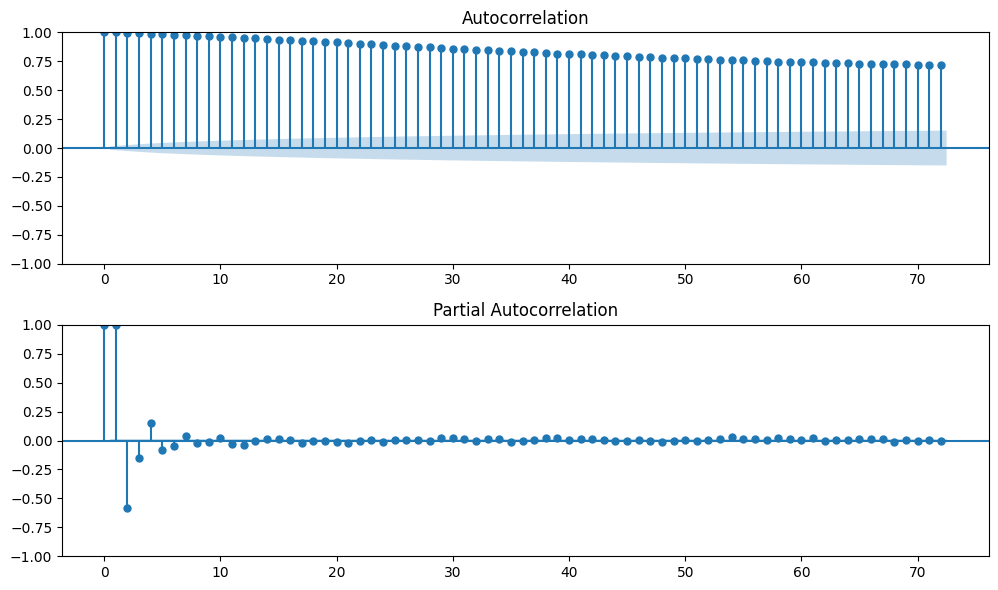

In [11]:
import pandas as pd
import numpy as np
from supabase import create_client
from dotenv import load_dotenv
import os
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

load_dotenv()
supabase = create_client(os.getenv("SUPABASE_URL"), os.getenv("SUPABASE_KEY"))

def load_location(name):
    all_rows = []
    offset = 0
    page_size = 1000
    while True:
        result = supabase.table("silver_hourly").select("*") \
            .eq("location_name", name).order("timestamp") \
            .range(offset, offset + page_size - 1).execute()
        if not result.data:
            break
        all_rows.extend(result.data)
        offset += page_size
    df = pd.DataFrame(all_rows)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    return df.set_index("timestamp").sort_index()

galle = load_location("Galle")
series = galle["wave_height"].asfreq("H")  # enforce hourly frequency, exposes any gaps as NaN
print(f"Total hours: {len(series)}, NaNs after freq enforcement: {series.isna().sum()}")

# Holdout: final 48 hours as test set, matching the proposal's forecast target
train, test = series.iloc[:-48], series.iloc[-48:]

# Try auto_arima first; fall back to manual grid if pmdarima isn't usable
try:
    import pmdarima as pm
    print("Running auto_arima (constrained search)...")
    model = pm.auto_arima(
        train, seasonal=True, m=24,
        max_p=3, max_q=3, max_P=2, max_Q=2, max_D=1, max_d=2,
        stepwise=True, trace=True, error_action="ignore", suppress_warnings=True,
    )
    order, seasonal_order = model.order, model.seasonal_order
    print(f"auto_arima selected: order={order}, seasonal_order={seasonal_order}")
except ImportError:
    print("pmdarima unavailable — falling back to manual AIC grid (see fallback block).")
    order, seasonal_order = None, None

# Diagnostics on the chosen order — this is the part the report actually needs
adf_result = adfuller(train.dropna())
print(f"ADF on training series: stat={adf_result[0]:.3f}, p={adf_result[1]:.4f}")

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(train.dropna(), lags=72, ax=axes[0])
plot_pacf(train.dropna(), lags=72, ax=axes[1])
plt.tight_layout()
plt.savefig("galle_sarima_diagnostics.png", dpi=150)
plt.show()

if order is not None:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    final_model = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                           enforce_stationarity=False, enforce_invertibility=False)
    fitted = final_model.fit(disp=False)

    forecast = fitted.get_forecast(steps=48)
    pred_mean = forecast.predicted_mean
    conf_int = forecast.conf_int()

    rmse = np.sqrt(np.mean((pred_mean.values - test.values) ** 2))
    mae = np.mean(np.abs(pred_mean.values - test.values))
    print(f"\n48-hour holdout — RMSE: {rmse:.3f} m, MAE: {mae:.3f} m")

    fig, ax = plt.subplots(figsize=(12, 5))
    train.iloc[-168:].plot(ax=ax, label="Train (last week)")
    test.plot(ax=ax, label="Actual (holdout)")
    pred_mean.plot(ax=ax, label="Forecast", style="--")
    ax.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], alpha=0.2)
    ax.set_title(f"Galle — 48-hour Wave Height Forecast vs Actual (order={order}, seasonal={seasonal_order})")
    ax.legend()
    plt.tight_layout()
    plt.savefig("galle_sarima_forecast.png", dpi=150)
    plt.show()

    # Residual diagnostics — required to claim the model is well-specified
    fitted.plot_diagnostics(figsize=(10, 8))
    plt.tight_layout()
    plt.savefig("galle_sarima_residuals.png", dpi=150)
    plt.show()

In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
import warnings
warnings.filterwarnings("ignore")

# Manual constrained grid — small ranges only, hourly SARIMAX with m=24 is expensive.
# Testing d=0 and d=1 given the ADF/ACF tension noted above, rather than trusting ADF alone.
p_range = range(0, 3)
d_range = [0, 1]
q_range = range(0, 3)
P_range = range(0, 2)
D_range = [0, 1]
Q_range = range(0, 2)
m = 24

best_aic = np.inf
best_order = None
best_seasonal_order = None
results_log = []

# Use a smaller slice for the search itself — full 17k-point SARIMAX fits are slow;
# search on a representative recent window, then refit the winner on full train data.
search_series = train.iloc[-2160:]  # last 90 days for the search phase

for p, d, q in itertools.product(p_range, d_range, q_range):
    for P, D, Q in itertools.product(P_range, D_range, Q_range):
        try:
            model = SARIMAX(search_series, order=(p, d, q),
                             seasonal_order=(P, D, Q, m),
                             enforce_stationarity=False, enforce_invertibility=False)
            fit = model.fit(disp=False, maxiter=50)
            results_log.append((p, d, q, P, D, Q, fit.aic))
            if fit.aic < best_aic:
                best_aic = fit.aic
                best_order = (p, d, q)
                best_seasonal_order = (P, D, Q, m)
        except Exception:
            continue

print(f"Best order from grid search: {best_order}, seasonal={best_seasonal_order}, AIC={best_aic:.1f}")
order, seasonal_order = best_order, best_seasonal_order

Best order from grid search: (2, 1, 2), seasonal=(0, 0, 0, 24), AIC=-11112.3


Fitting SARIMAX with order=(2, 1, 2), seasonal_order=(0, 0, 0, 24)
ADF on training series: stat=-6.165, p=0.0000


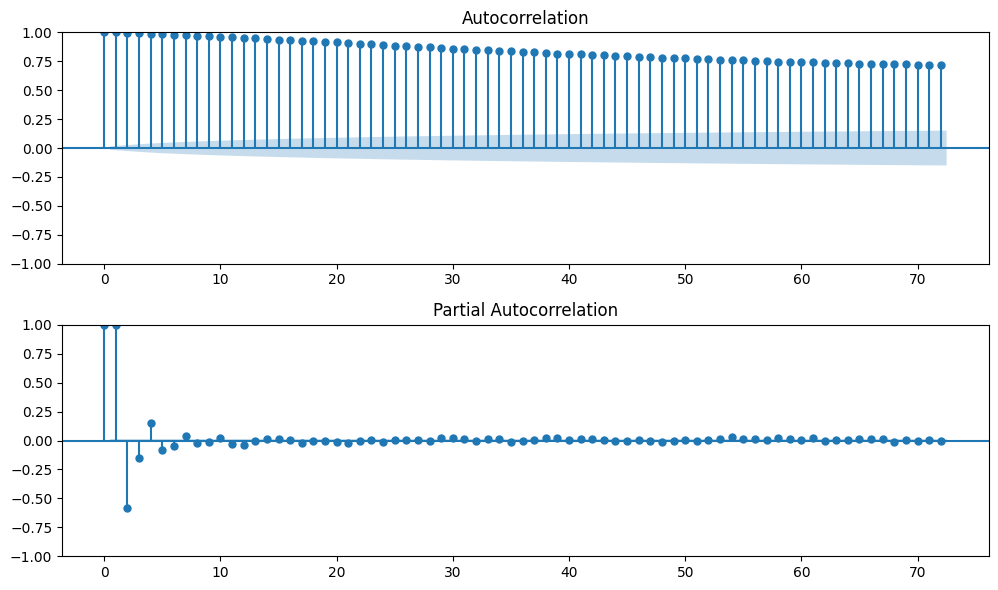


48-hour holdout — RMSE: 0.045 m, MAE: 0.036 m


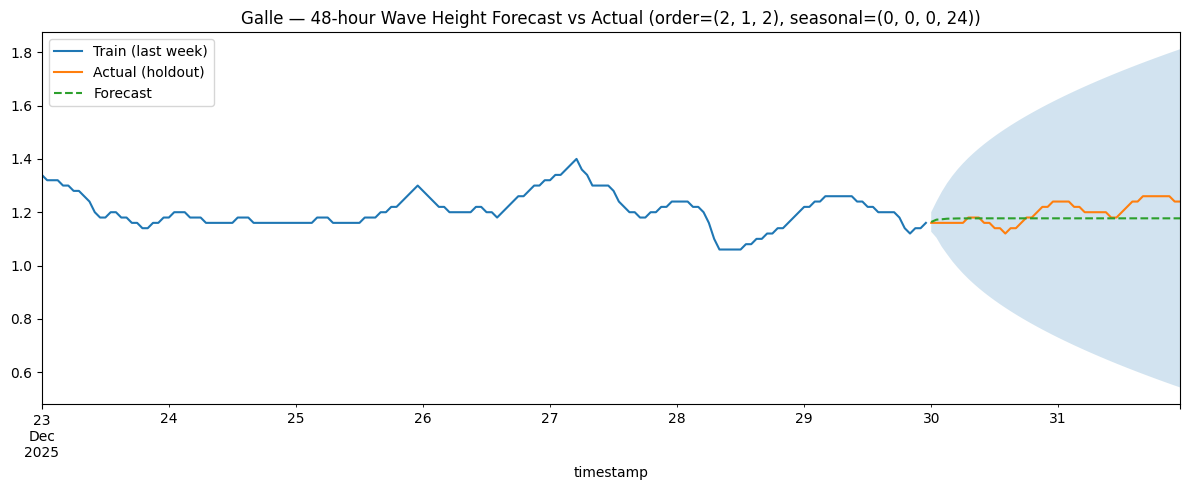

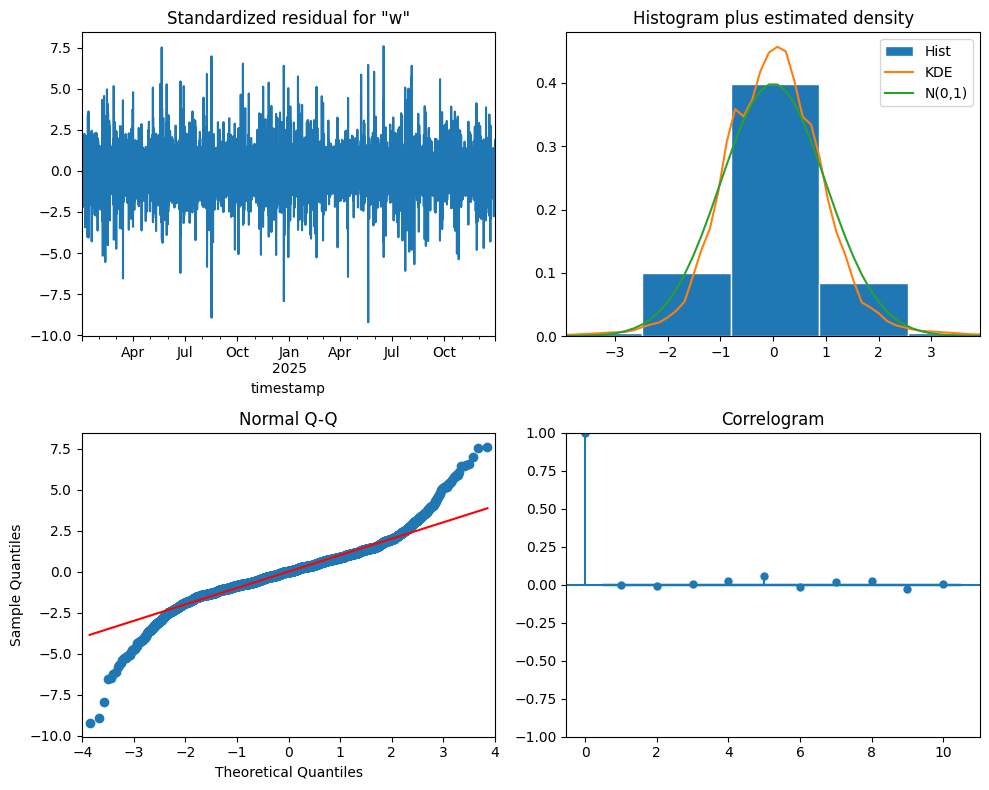

In [13]:
import pandas as pd
import numpy as np
from supabase import create_client
from dotenv import load_dotenv
import os
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

load_dotenv()
supabase = create_client(os.getenv("SUPABASE_URL"), os.getenv("SUPABASE_KEY"))

def load_location(name):
    all_rows = []
    offset = 0
    page_size = 1000
    while True:
        result = supabase.table("silver_hourly").select("*") \
            .eq("location_name", name).order("timestamp") \
            .range(offset, offset + page_size - 1).execute()
        if not result.data:
            break
        all_rows.extend(result.data)
        offset += page_size
    df = pd.DataFrame(all_rows)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    return df.set_index("timestamp").sort_index()

galle = load_location("Galle")
series = galle["wave_height"].asfreq("h")
train, test = series.iloc[:-48], series.iloc[-48:]

# Using the grid search result from the previous step directly —
# do not re-attempt pmdarima import here, it will fail again silently.
order = (2, 1, 2)
seasonal_order = (0, 0, 0, 24)
print(f"Fitting SARIMAX with order={order}, seasonal_order={seasonal_order}")

adf_result = adfuller(train.dropna())
print(f"ADF on training series: stat={adf_result[0]:.3f}, p={adf_result[1]:.4f}")

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(train.dropna(), lags=72, ax=axes[0])
plot_pacf(train.dropna(), lags=72, ax=axes[1])
plt.tight_layout()
plt.savefig("galle_sarima_diagnostics.png", dpi=150)
plt.show()

final_model = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                       enforce_stationarity=False, enforce_invertibility=False)
fitted = final_model.fit(disp=False)

forecast = fitted.get_forecast(steps=48)
pred_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

rmse = np.sqrt(np.mean((pred_mean.values - test.values) ** 2))
mae = np.mean(np.abs(pred_mean.values - test.values))
print(f"\n48-hour holdout — RMSE: {rmse:.3f} m, MAE: {mae:.3f} m")

fig, ax = plt.subplots(figsize=(12, 5))
train.iloc[-168:].plot(ax=ax, label="Train (last week)")
test.plot(ax=ax, label="Actual (holdout)")
pred_mean.plot(ax=ax, label="Forecast", style="--")
ax.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], alpha=0.2)
ax.set_title(f"Galle — 48-hour Wave Height Forecast vs Actual (order={order}, seasonal={seasonal_order})")
ax.legend()
plt.tight_layout()
plt.savefig("galle_sarima_forecast.png", dpi=150)
plt.show()

fitted.plot_diagnostics(figsize=(10, 8))
plt.tight_layout()
plt.savefig("galle_sarima_residuals.png", dpi=150)
plt.show()

In [14]:
naive_forecast = np.full(48, train.iloc[-1])
naive_rmse = np.sqrt(np.mean((naive_forecast - test.values) ** 2))
naive_mae = np.mean(np.abs(naive_forecast - test.values))
print(f"Naive persistence baseline — RMSE: {naive_rmse:.3f} m, MAE: {naive_mae:.3f} m")
print(f"SARIMA RMSE: 0.045 m, MAE: 0.036 m")
print(f"SARIMA improvement over naive: {(1 - 0.045/naive_rmse)*100:.1f}% RMSE reduction" if naive_rmse > 0 else "")

Naive persistence baseline — RMSE: 0.055 m, MAE: 0.043 m
SARIMA RMSE: 0.045 m, MAE: 0.036 m
SARIMA improvement over naive: 18.5% RMSE reduction


In [17]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

series = galle["wave_height"].asfreq("h")

order = (2, 1, 2)
seasonal_order = (0, 0, 0, 24)

holdout_origins = [
    "2025-02-15",
    "2025-06-15",
    "2025-08-15",
    "2025-10-15",
    "2025-12-30",
]

results = []

for origin_str in holdout_origins:
    origin = pd.Timestamp(origin_str, tz="UTC")  # match the tz-aware index from Supabase
    train = series[series.index < origin]
    test = series[(series.index >= origin) & (series.index < origin + pd.Timedelta(hours=48))]

    if len(test) < 48 or train.isna().any() or len(train) < 24 * 90:
        print(f"Skipping {origin_str} — insufficient train/test data")
        continue

    try:
        model = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                         enforce_stationarity=False, enforce_invertibility=False)
        fitted = model.fit(disp=False, maxiter=50)
        forecast = fitted.get_forecast(steps=48).predicted_mean

        sarima_rmse = np.sqrt(np.mean((forecast.values - test.values) ** 2))
        sarima_mae = np.mean(np.abs(forecast.values - test.values))

        naive = np.full(48, train.iloc[-1])
        naive_rmse = np.sqrt(np.mean((naive - test.values) ** 2))
        naive_mae = np.mean(np.abs(naive - test.values))

        improvement = (1 - sarima_rmse / naive_rmse) * 100 if naive_rmse > 0 else np.nan

        results.append({
            "holdout_start": origin_str,
            "actual_wave_range": f"{test.min():.2f}-{test.max():.2f} m",
            "sarima_rmse": round(sarima_rmse, 3),
            "sarima_mae": round(sarima_mae, 3),
            "naive_rmse": round(naive_rmse, 3),
            "naive_mae": round(naive_mae, 3),
            "rmse_improvement_pct": round(improvement, 1),
        })
        print(f"{origin_str}: SARIMA RMSE={sarima_rmse:.3f}, naive RMSE={naive_rmse:.3f}, improvement={improvement:.1f}%")

    except Exception as e:
        print(f"Failed for {origin_str}: {e}")

results_df = pd.DataFrame(results)
print("\n", results_df.to_string(index=False))
results_df.to_csv("galle_sarima_backtest_results.csv", index=False)

2025-02-15: SARIMA RMSE=0.131, naive RMSE=0.145, improvement=9.6%
2025-06-15: SARIMA RMSE=0.233, naive RMSE=0.249, improvement=6.6%
2025-08-15: SARIMA RMSE=0.205, naive RMSE=0.224, improvement=8.4%
2025-10-15: SARIMA RMSE=0.144, naive RMSE=0.190, improvement=24.0%
2025-12-30: SARIMA RMSE=0.045, naive RMSE=0.055, improvement=18.6%

 holdout_start actual_wave_range  sarima_rmse  sarima_mae  naive_rmse  naive_mae  rmse_improvement_pct
   2025-02-15       0.98-1.36 m        0.131       0.099       0.145      0.106                   9.6
   2025-06-15       2.26-2.82 m        0.233       0.193       0.249      0.205                   6.6
   2025-08-15       1.80-2.16 m        0.205       0.170       0.224      0.192                   8.4
   2025-10-15       1.78-2.10 m        0.144       0.120       0.190      0.166                  24.0
   2025-12-30       1.12-1.26 m        0.045       0.036       0.055      0.043                  18.6
